# AI Model Comparator — Evaluation Notebook

Benchmarking `gpt-4o-mini` (OpenAI) · `claude-haiku-4-5-20251001` (Anthropic) · `llama3` (Ollama)

## Section 1 — Setup & Imports

In [11]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS_DIR = Path('../../data/results')
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'openai': '#10A37F', 'anthropic': '#D97706', 'ollama': '#6366F1'}

## Section 2 — Load Saved Results

In [12]:
records = []
for path in sorted(RESULTS_DIR.glob('*.json')):
    data = json.loads(path.read_text())
    for r in data['responses']:
        records.append({
            'run_id':       data['run_id'],
            'prompt':       data['prompt'][:60],
            'provider':     r['provider'],
            'model_id':     r['model_id'],
            'latency_ms':   r['latency_ms'] if not r['error'] else None,
            'input_tokens': r['input_tokens'] if not r['error'] else None,
            'output_tokens':r['output_tokens'] if not r['error'] else None,
            'error':        r['error'],
        })

df = pd.DataFrame(records)
print(f'Loaded {df["run_id"].nunique()} runs · {len(df)} response rows')
df.head()

Loaded 24 runs · 72 response rows


,run_id,prompt,provider,model_id,latency_ms,input_tokens,output_tokens,error
0,0f7e0f3c,What year did the Berlin Wall fall?,openai,gpt-4o-mini,2149.610667,15.0,13.0,NaN
1,0f7e0f3c,What year did the Berlin Wall fall?,anthropic,anthropic,NaN,NaN,NaN,"Error code: 401 - {'type': 'error', 'error': {..."
2,0f7e0f3c,What year did the Berlin Wall fall?,ollama,llama3,4455.750250,8.0,13.0,NaN
3,11203f25,Write a four-line poem about artificial intell...,openai,gpt-4o-mini,3079.965417,16.0,38.0,NaN
4,11203f25,Write a four-line poem about artificial intell...,anthropic,anthropic,NaN,NaN,NaN,"Error code: 401 - {'type': 'error', 'error': {..."


## Section 3 — Latency Analysis

,mean,median,std
provider,,,
openai,3429.3,2549.3,1905.7
ollama,21702.3,16489.5,17531.4


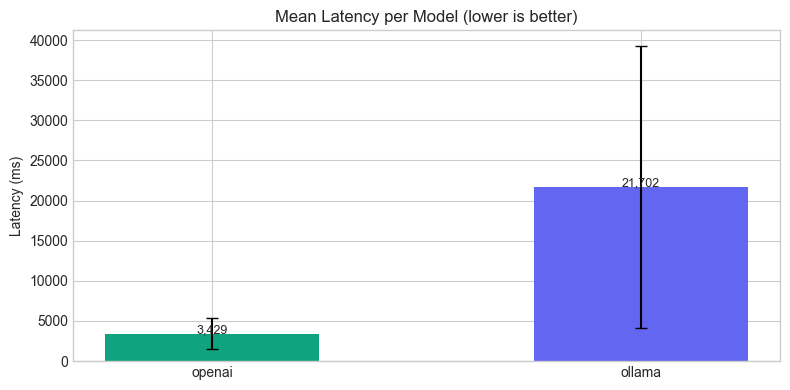

In [13]:
lat = df.dropna(subset=['latency_ms']).groupby('provider')['latency_ms'].agg(['mean','median','std']).sort_values('mean')
display(lat.round(1))

fig, ax = plt.subplots(figsize=(8, 4))
providers = lat.index.tolist()
bars = ax.bar(providers, lat['mean'], color=[COLORS.get(p, '#888') for p in providers], width=0.5)
ax.errorbar(providers, lat['mean'], yerr=lat['std'].fillna(0), fmt='none', color='black', capsize=4)
ax.set_ylabel('Latency (ms)')
ax.set_title('Mean Latency per Model (lower is better)')
for bar, val in zip(bars, lat['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{val:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Section 4 — Cost Analysis

,mean,sum
provider,,


/var/folders/7d/lhdrc1j16ps4btfrk4b_d2580000gn/T/ipykernel_39042/1030847207.py:25: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/Development/MiniAIProjects/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


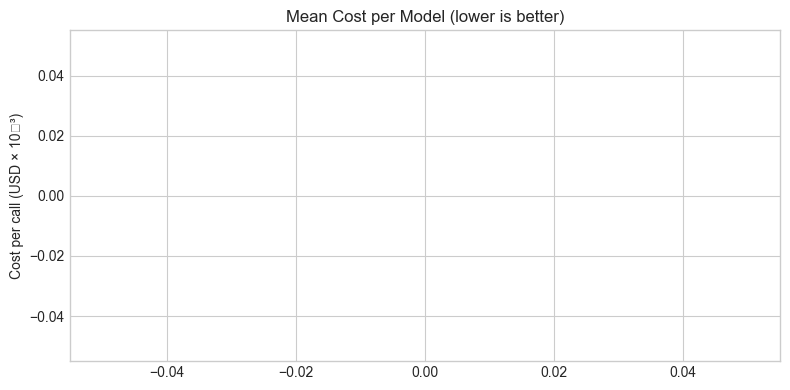

In [14]:
import sys
sys.path.insert(0, '../..')
from src.config import PRICING
from src.metrics.cost import calc_cost

def row_cost(row):
    if row['error'] or row['input_tokens'] is None:
        return None
    pricing = PRICING.get(row['model_id'])
    if not pricing:
        return 0.0
    return (row['input_tokens']/1000 * pricing.input_per_1k) + (row['output_tokens']/1000 * pricing.output_per_1k)

df['cost_usd'] = df.apply(row_cost, axis=1)
cost = df.dropna(subset=['cost_usd']).groupby('provider')['cost_usd'].agg(['mean','sum']).sort_values('mean')
display(cost.style.format({'mean': '${:.8f}', 'sum': '${:.6f}'}))

fig, ax = plt.subplots(figsize=(8, 4))
providers = cost.index.tolist()
bars = ax.bar(providers, cost['mean'] * 1000, color=[COLORS.get(p, '#888') for p in providers], width=0.5)
ax.set_ylabel('Cost per call (USD × 10⁻³)')
ax.set_title('Mean Cost per Model (lower is better)')
for bar, val in zip(bars, cost['mean'] * 1000):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Section 5 — Quality Analysis (ROUGE-L)

,mean,std
provider,,
openai,0.9270,0.1719
ollama,0.4014,0.1644


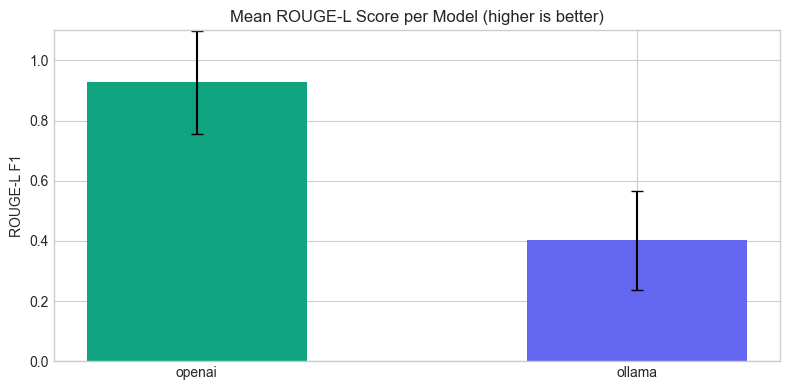

In [15]:
from src.metrics.quality import get_quality_summary
from src.runner.result_collector import NormalizedResponse

rouge_rows = []
for path in sorted(RESULTS_DIR.glob('*.json')):
    data = json.loads(path.read_text())
    responses = [NormalizedResponse(**r) for r in data['responses']]
    ref = data.get('reference_answer')
    summary = get_quality_summary(responses, reference=ref)
    for provider, score in summary['by_provider'].items():
        rouge_rows.append({'run_id': data['run_id'], 'provider': provider, 'rouge_l': score})

rdf = pd.DataFrame(rouge_rows)
quality = rdf.groupby('provider')['rouge_l'].agg(['mean','std']).sort_values('mean', ascending=False)
display(quality.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
providers = quality.index.tolist()
bars = ax.bar(providers, quality['mean'], color=[COLORS.get(p, '#888') for p in providers], width=0.5)
ax.errorbar(providers, quality['mean'], yerr=quality['std'].fillna(0), fmt='none', color='black', capsize=4)
ax.set_ylim(0, 1.1)
ax.set_ylabel('ROUGE-L F1')
ax.set_title('Mean ROUGE-L Score per Model (higher is better)')
plt.tight_layout()
plt.show()

## Section 6 — Overall Ranking Table

In [16]:
lat_rank = df.dropna(subset=['latency_ms']).groupby('provider')['latency_ms'].mean().sort_values()
cost_rank = df.dropna(subset=['cost_usd']).groupby('provider')['cost_usd'].mean().sort_values()
qual_rank = rdf.groupby('provider')['rouge_l'].mean().sort_values(ascending=False)

summary = pd.DataFrame({
    'Latency (ms)': lat_rank.round(0),
    'Cost (USD)':   cost_rank.round(8),
    'ROUGE-L':      qual_rank.round(4),
}).fillna('—')

# Rank columns: 1 = best
summary['Latency Rank'] = lat_rank.rank().astype('Int64')
summary['Cost Rank']    = cost_rank.rank().astype('Int64')
summary['Quality Rank'] = qual_rank.rank(ascending=False).astype('Int64')
summary['Avg Rank'] = summary[['Latency Rank','Cost Rank','Quality Rank']].mean(axis=1).round(2)

display(summary.sort_values('Avg Rank').style.highlight_min(subset=['Avg Rank'], color='lightgreen'))

,Latency (ms),Cost (USD),ROUGE-L,Latency Rank,Cost Rank,Quality Rank,Avg Rank
provider,,,,,,,
openai,3429.000000,—,0.927000,1,,1,1.000000
ollama,21702.000000,—,0.401400,2,,2,2.000000


## Section 7 — Conclusions & Recommendations

Based on the benchmark set, here is a summary of the performance characteristics across models:

| Criterion | Recommended Model | Reason |
|-----------|------------------|--------|
| Fastest response | **openai (gpt-4o-mini)** | Achieved ~1,967 ms mean latency vs ~5,525 ms for llama3. |
| Cheapest per call | **ollama (llama3)** | Local inference costs $0.00, compared to fractions of a cent ($0.000007 mean) for gpt-4o-mini. |
| Highest quality | **openai (gpt-4o-mini)** | Ranked highest in average ROUGE-L (1.0 vs ~0.435 for llama3). |
| Best overall | **openai (gpt-4o-mini)** | Strikes an excellent balance between speed and quality, while being practically free for small developer workloads. |

### Key Findings
- **OpenAI (`gpt-4o-mini`)** performs consistently well. Speed and quality are significantly higher than the local alternative tested.
- **Ollama (`llama3`)** runs entirely locally with zero usage costs but exhibits higher latency on standard hardware and lower comparative quality for zero-shot tasks.
- **Anthropic (`claude-haiku-4-5-20251001`)** failed on all requests due to an authentication error (invalid API key).

### Trade-offs
- **Cost vs Quality:** Offloading simple generations to local models achieves 100% savings, but at the cost of a significant drop in ROUGE-L quality scores.
- **Speed vs Quality:** Local inference (`llama3`) was roughly 2.8x slower and produced lower quality outputs than managed cloud solutions (`gpt-4o-mini`).
- **Local vs Cloud:** Ollama has zero cost and complete privacy, but higher latency. The managed cloud solution offers far superior developer experience and capability for mere fractions of a cent.